# Randomization Comparison

This notebook studies how the number of randomized runs affects the solution quality and runtime of the final local-search configuration.

For every instance, the configuration was executed 50 times using different random seeds.

The notebook investigates how many randomized runs provide a good compromise between solution quality and computational effort.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("default")

## Configuration

The following configuration defines the analyzed step counts, numerical tolerance, result directories, and output directory.

In [2]:
MAX_RUNS = 50
RUN_COUNTS = list(range(1, MAX_RUNS + 1))

GRAPH_ORDER = ["powerlaw", "er"]

DATASET_ORDER = [
    "small sparse",
    "small dense",
    "large sparse",
    "large dense",
]

PIPELINE = ",".join(["move_plateau"] * 4)

START_PARTITION = "maximum_matching"
ZERO_GAIN_FACTOR = 4

RESULTS_DIR = Path("../results/experiment2/randomization")

RAW_RESULTS_FILE = RESULTS_DIR / "raw_results.csv"

## Load and verify experiment data

Before the analysis, the notebook lists the contained pipelines, start partitions, zero-gain factors, number of runs, and number of recorded steps. This provides a compact check that the intended experiment results were loaded.

In [3]:
raw_all = pd.read_csv(RAW_RESULTS_FILE)

required_columns = {
    "experiment",
    "pipeline",
    "start_partition",
    "zero_gain_factor",
    "run",
    "graph_type",
    "size_class",
    "regime",
    "dataset",
    "instance",
    "final_density",
    "ls_runtime",
}

missing_columns = required_columns.difference(raw_all.columns)

if missing_columns:
    raise ValueError("Missing required columns: " + ", ".join(sorted(missing_columns)))

experiment_check = (
    raw_all
    .groupby(
        [
            "pipeline",
            "start_partition",
            "zero_gain_factor",
        ],
        dropna=False,
        as_index=False,
    )
    .agg(
        num_runs=("run", "nunique"),
        num_instances=("instance", "nunique"),
        num_rows=("run", "size"),
    )
    .sort_values(
        [
            "pipeline",
            "start_partition",
            "zero_gain_factor",
        ],
        na_position="first",
    )
    .reset_index(drop=True)
)

print(f"Loaded {len(raw_all):,} rows from {RAW_RESULTS_FILE}")

experiment_check

Loaded 100,000 rows from ../results/experiment2/randomization/raw_results.csv


,pipeline,start_partition,zero_gain_factor,num_runs,num_instances,num_rows
0,"move_plateau,move_plateau,move_plateau,move_pl...",maximum_matching,4,50,2000,100000


## Prepare randomization experiment

Only the final local-search configuration is retained.

The run numbers are interpreted as an ordered sequence of randomized executions. For every $k \in \{1,\dots,50\}$, the analysis considers the best solution found among the first $k$ runs.

In [4]:
raw_all["dataset_group"] = (
        raw_all["size_class"].astype(str)
        + " "
        + raw_all["regime"].astype(str)
)

raw_all["graph_type"] = pd.Categorical(
    raw_all["graph_type"],
    categories=GRAPH_ORDER,
    ordered=True,
)

raw_all["dataset_group"] = pd.Categorical(
    raw_all["dataset_group"],
    categories=DATASET_ORDER,
    ordered=True,
)

randomization_raw = raw_all[
    (raw_all["pipeline"] == PIPELINE)
    & (raw_all["start_partition"] == START_PARTITION)
    & (raw_all["zero_gain_factor"] == ZERO_GAIN_FACTOR)
    ].copy()

if randomization_raw.empty:
    raise ValueError("No rows found for the expected randomization experiment.")

observed_runs = sorted(
    randomization_raw["run"]
    .dropna()
    .astype(int)
    .unique()
)

if len(observed_runs) != MAX_RUNS:
    raise ValueError(f"Expected {MAX_RUNS} runs, but found {len(observed_runs)}.")

randomization_raw = randomization_raw.sort_values("run").copy()

run_order = {run: i + 1 for i, run in enumerate(observed_runs)}

randomization_raw["run_number"] = randomization_raw["run"].map(run_order)


## Solution quality

For every instance and number of randomized runs $k$, the best solution obtained among the first $k$ runs is retained.

The best solution obtained across all 50 runs serves as the reference. Relative solution quality for $k$ runs is defined as

$
\frac{\text{best score across all 50 runs}}
     {\text{best score across the first }k\text{ runs}}.
$

A value of $1.0$ indicates that the first $k$ randomized runs already contain the best solution found across all 50 runs. Values greater than $1.0$ indicate the remaining quality gap.

In [5]:
instance_keys = [
    "graph_type",
    "dataset_group",
    "dataset",
    "instance",
]

randomization_sorted = (
    randomization_raw
    .sort_values(instance_keys + ["run_number"])
    .copy()
)

randomization_sorted["best_density_so_far"] = (
    randomization_sorted
    .groupby(instance_keys, observed=True)["final_density"]
    .cummax()
)

run_scores = (
    randomization_sorted
    .pivot(
        index=instance_keys,
        columns="run_number",
        values="best_density_so_far",
    )
)

run_scores = run_scores[RUN_COUNTS]
run_scores.columns.name = "num_runs"

if run_scores.isna().any().any():
    incomplete_instances = run_scores[run_scores.isna().any(axis=1)]

    raise ValueError(f"{len(incomplete_instances)} instances do not contain all 50 runs.")

In [6]:
reference_score = run_scores[MAX_RUNS]

relative_quality = run_scores.rdiv(reference_score, axis=0)

relative_quality.columns.name = "num_runs"

relative_quality_summary = (
    relative_quality
    .groupby(level=["graph_type", "dataset_group"])
    .mean()
    .stack()
    .rename("mean_relative_quality")
    .reset_index()
)

relative_quality_summary = relative_quality_summary[
    (relative_quality_summary["num_runs"] == 1)
    | (relative_quality_summary["num_runs"] % 5 == 0)
]

relative_quality_summary

,graph_type,dataset_group,num_runs,mean_relative_quality
0,powerlaw,small sparse,1,1.009041
4,powerlaw,small sparse,5,1.003504
9,powerlaw,small sparse,10,1.002068
14,powerlaw,small sparse,15,1.001529
19,powerlaw,small sparse,20,1.001098
...,...,...,...,...
379,er,large dense,30,1.001034
384,er,large dense,35,1.000622
389,er,large dense,40,1.000389
394,er,large dense,45,1.000249


## Relative solution quality by dataset group

The following figures show how the mean relative solution quality develops as additional randomized runs are considered.

The result obtained from all 50 runs serves as the reference.

In [7]:
GRAPH_TYPE_LABELS = {
    "er": "Erdős–Rényi",
    "powerlaw": "Powerlaw",
}

In [8]:
def plot_relative_quality(
        summary: pd.DataFrame,
        graph_type: str,
        output_path: str | None = None,
) -> None:
    graph_data = (
        summary[
            summary["graph_type"] == graph_type
            ]
        .sort_values(
            [
                "dataset_group",
                "num_runs",
            ]
        )
    )

    fig, ax = plt.subplots(figsize=(8, 5))

    for dataset_group, group_data in graph_data.groupby(
            "dataset_group",
            observed=True,
    ):
        ax.plot(
            group_data["num_runs"],
            group_data["mean_relative_quality"],
            marker="o",
            linewidth=2,
            markersize=4,
            label=dataset_group,
        )

    ax.axhline(
        1.0,
        linestyle="--",
        color="gray",
        linewidth=1,
        label="50 Runs",
    )

    ax.set_xlabel("Anzahl berücksichtigter Runs")
    ax.set_ylabel("Mittlere relative Lösungsqualität")
    ax.set_title(
        f"Relative Lösungsqualität "
        f"({GRAPH_TYPE_LABELS[graph_type]})"
    )

    ax.set_xticks(
        [1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
    )

    ax.legend(title="Datensatzgruppe")
    ax.grid(axis="y", alpha=0.3)

    fig.tight_layout()

    if output_path is not None:
        fig.savefig(
            output_path,
            bbox_inches="tight",
            facecolor="white",
        )

    plt.show()
    plt.close(fig)

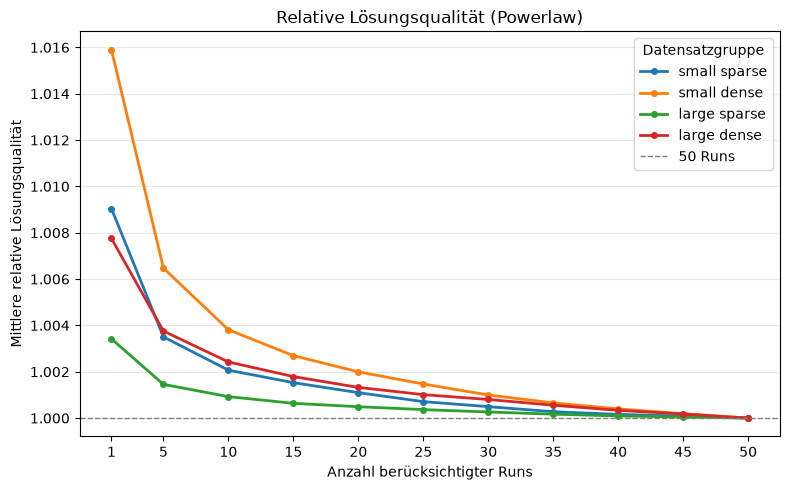

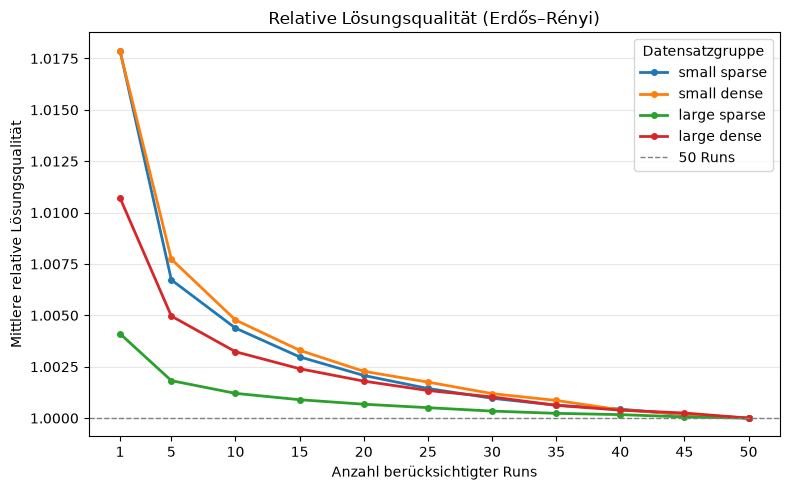

In [9]:
plot_relative_quality(
    relative_quality_summary,
    "powerlaw",
    "../results/plots/powerlaw_randomization_quality.png",
)

plot_relative_quality(
    relative_quality_summary,
    "er",
    "../results/plots/er_randomization_quality.png",
)

## Runtime

For every instance, the runtimes of the randomized runs are accumulated in execution order.

The cumulative runtime after $k$ runs therefore represents the total computational effort required to obtain the best solution among these $k$ randomized executions.

These cumulative runtimes are averaged over all instances in the corresponding graph and dataset group.

In [10]:
randomization_sorted["cumulative_runtime"] = (
    randomization_sorted
    .groupby(
        instance_keys,
        observed=True,
    )["ls_runtime"]
    .cumsum()
)

runtime_summary = (
    randomization_sorted
    .groupby(
        [
            "graph_type",
            "dataset_group",
            "run_number",
        ],
        observed=True,
        as_index=False,
    )
    .agg(
        mean_total_runtime=(
            "cumulative_runtime",
            "mean",
        )
    )
    .rename(
        columns={
            "run_number": "num_runs",
        }
    )
)

runtime_summary = runtime_summary[
    (runtime_summary["num_runs"] == 1)
    | (runtime_summary["num_runs"] % 5 == 0)
    ]

runtime_summary

,graph_type,dataset_group,num_runs,mean_total_runtime
0,powerlaw,small sparse,1,1.895455
4,powerlaw,small sparse,5,9.515276
9,powerlaw,small sparse,10,19.187016
14,powerlaw,small sparse,15,28.854973
19,powerlaw,small sparse,20,38.424403
...,...,...,...,...
379,er,large dense,30,1131.202059
384,er,large dense,35,1312.631569
389,er,large dense,40,1494.890796
394,er,large dense,45,1674.131272


In [11]:
def plot_total_runtime(
        summary: pd.DataFrame,
        graph_type: str,
        output_path: str | None = None,
) -> None:
    graph_data = (
        summary[
            summary["graph_type"] == graph_type
            ]
        .sort_values(
            [
                "dataset_group",
                "num_runs",
            ]
        )
    )

    fig, ax = plt.subplots(figsize=(8, 5))

    for dataset_group, group_data in graph_data.groupby(
            "dataset_group",
            observed=True,
    ):
        ax.plot(
            group_data["num_runs"],
            group_data["mean_total_runtime"],
            marker="o",
            linewidth=2,
            markersize=4,
            label=dataset_group,
        )

    ax.set_xlabel("Anzahl berücksichtigter Runs")
    ax.set_ylabel("Mittlere Gesamtlaufzeit (s)")
    ax.set_title(
        f"Gesamtlaufzeit "
        f"({GRAPH_TYPE_LABELS[graph_type]})"
    )

    ax.set_xticks(
        [1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
    )

    ax.legend(title="Datensatzgruppe")
    ax.grid(axis="y", alpha=0.3)

    fig.tight_layout()

    if output_path is not None:
        fig.savefig(
            output_path,
            bbox_inches="tight",
            facecolor="white",
        )

    plt.show()
    plt.close(fig)

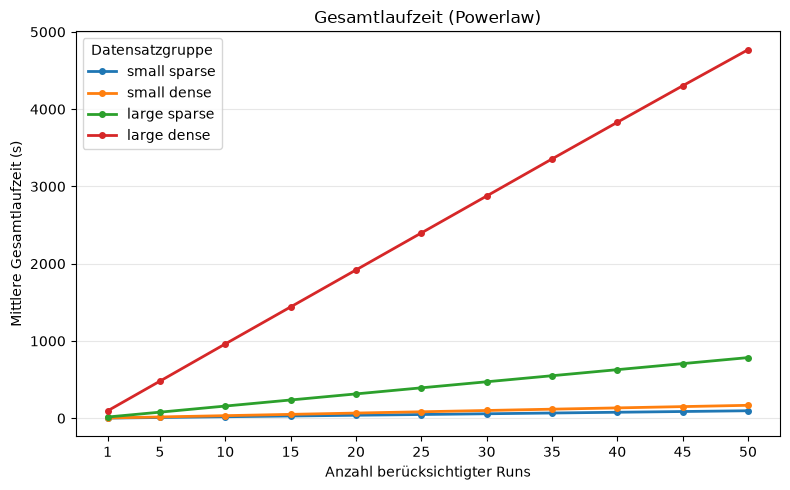

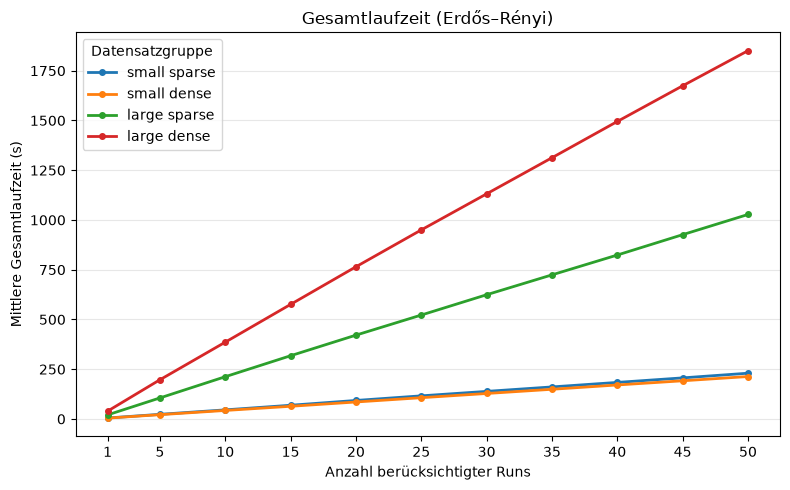

In [12]:
plot_total_runtime(
    runtime_summary,
    "powerlaw",
    "../results/plots/powerlaw_randomization_runtime.png",
)

plot_total_runtime(
    runtime_summary,
    "er",
    "../results/plots/er_randomization_runtime.png",
)

## Combined comparison data

In [13]:
comparison_summary = (
    relative_quality_summary
    .merge(
        runtime_summary,
        on=[
            "graph_type",
            "dataset_group",
            "num_runs",
        ],
    )
)

comparison_summary["num_runs"] = pd.Categorical(
    comparison_summary["num_runs"],
    categories=RUN_COUNTS,
    ordered=True,
)

comparison_summary = (
    comparison_summary
    .sort_values(
        [
            "graph_type",
            "dataset_group",
            "num_runs",
        ]
    )
    .reset_index(drop=True)
)

comparison_summary

,graph_type,dataset_group,num_runs,mean_relative_quality,mean_total_runtime
0,powerlaw,small sparse,1,1.009041,1.895455
1,powerlaw,small sparse,5,1.003504,9.515276
2,powerlaw,small sparse,10,1.002068,19.187016
3,powerlaw,small sparse,15,1.001529,28.854973
4,powerlaw,small sparse,20,1.001098,38.424403
...,...,...,...,...,...
83,er,large dense,30,1.001034,1131.202059
84,er,large dense,35,1.000622,1312.631569
85,er,large dense,40,1.000389,1494.890796
86,er,large dense,45,1.000249,1674.131272
